# Learning to learn better by optimising batch size using Bayes Opt

In this tutorial, you will be using Bayes Opt to tune the batch size for a NN.

Please refer to the lecture slides for pseudo-code on Bayes Opt.

You will be using the segmentation network from last lab session and your goal would be to build a meta-learning system that can give you an optimal batch size.

You should use Bayes Opt along with the one or both networks that you trained in the last lab session to tune the batch size for one or both of the networks.

After training with the optimal batch size, compare your first model's performance with that of the one trained using the optimal batch size.

Batch size directly impacts the balance between training speed, generalization accuracy, and memory constraints. Too small of a batch size causes unstable training and thus poor perfomrnace, whereas too large of a batch size may take too long for training resulting in poor generalisability when trained with fixed compute budgets.

### Data download and extraction

In [1]:
!wget -O images_lab_data.zip https://github.com/s-sd/EMS741/raw/refs/heads/main/tutorials/images/images_lab_data.zip


import zipfile
import os

path_to_zip = r'images_lab_data.zip'
path_to_extract_to = r'./'

with zipfile.ZipFile(path_to_zip, 'r') as zip_ref:
    zip_ref.extractall(path_to_extract_to)


--2026-03-06 14:28:49--  https://github.com/s-sd/EMS741/raw/refs/heads/main/tutorials/images/images_lab_data.zip
Resolving github.com (github.com)... 140.82.114.3
Connecting to github.com (github.com)|140.82.114.3|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://raw.githubusercontent.com/s-sd/EMS741/refs/heads/main/tutorials/images/images_lab_data.zip [following]
--2026-03-06 14:28:49--  https://raw.githubusercontent.com/s-sd/EMS741/refs/heads/main/tutorials/images/images_lab_data.zip
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 23924619 (23M) [application/zip]
Saving to: ‘images_lab_data.zip’

images_lab_data.zip 100%[===================>]  22.82M   131MB/s    in 0.2s    

2026-03-06 14:28:50 (131 MB/s) - ‘images_lab

In [2]:
!ls

# we are interested in 'images' and 'masks'

images	images_lab_data.zip  masks  sample_data


### Data checks

Before you proceed with building your segmentation system, load in a single image and corresponding mask to verify that they are paired correctly. And to check their shapes etc. Hint: use the matplotlib imread function.

In [3]:
import matplotlib.pyplot as plt
import numpy as np

images_file_names = np.array(sorted(os.listdir('images')))
masks_file_names = np.array(sorted(os.listdir('masks')))

#shuffle the image and masks using the same order
shuffle_indexes = np.array(np.random.permutation(len(images_file_names)), dtype=np.int32)

images_file_names_shuffled = images_file_names[shuffle_indexes]
masks_file_names_shuffled = masks_file_names[shuffle_indexes]

print(images_file_names_shuffled[0], masks_file_names_shuffled[0])

sample_286_slice_007.png sample_286_slice_007.png


images/sample_320_slice_007.png masks/sample_320_slice_007.png


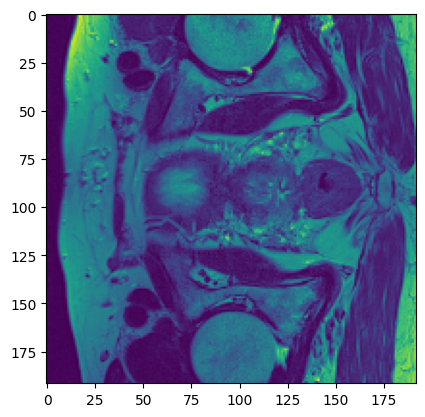

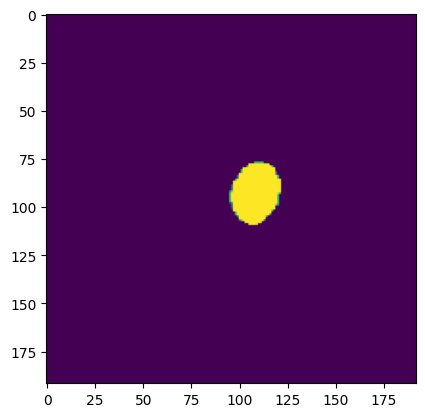

In [4]:
sample_number_to_plot = 10

image_path = os.path.join(r'images', images_file_names_shuffled[sample_number_to_plot])
mask_path = os.path.join(r'masks', masks_file_names_shuffled[sample_number_to_plot])

print(image_path, mask_path)

image = plt.imread(image_path)
mask = plt.imread(mask_path)

plt.imshow(image)

plt.figure()
plt.imshow(mask)

In [5]:
print(np.amin(image), np.amax(image))
print(np.amin(mask), np.amax(mask))
print(image.shape, mask.shape)

# this is what we can use to quickly get a classification label
# if the sum of all pixels in the mask is >1 then prostate exists
# if the sum is 0 then prostate does not exist
print(int(np.sum(mask, axis=None)>1))

0.0 1.0
0.0 1.0
(192, 192) (192, 192)
1


### Classification NN

This is the classification NN from last lab.

In [19]:
# python generator for classification

def my_classification_data_generator(batch_size, x_shape, y_shape, file_names, images_file_path, masks_file_path):

  while True:

    batch_x = np.zeros((batch_size, *x_shape))
    batch_y = np.zeros((batch_size, *y_shape))

    for i in range(batch_size):

      index = np.random.randint(len(file_names))

      image = plt.imread(os.path.join(images_file_path, file_names[index]))

      mask = plt.imread(os.path.join(masks_file_path, file_names[index]))
      classification = int(np.sum(mask, axis=None)>1)

      batch_x[i] = image
      batch_y[i] = classification

    batch_x = np.expand_dims(batch_x, axis=1) # as torch follows c, h, w

    yield batch_x, batch_y



In [20]:
import torch
import torch.nn as nn
import torch.optim as optim

# In PyTorch we use (C, H, W)
# where C=1

class MinimalAlexNet(nn.Module):
    def __init__(self, input_shape_chw):
        super().__init__()
        c, h, w = input_shape_chw

        self.features = nn.Sequential(
            nn.Conv2d(c, 64, kernel_size=11, stride=4, padding=5), nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=3, stride=2),
            nn.Conv2d(64, 192, kernel_size=5, stride=1, padding=2), nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=3, stride=2),
            nn.Conv2d(192, 384, kernel_size=3, stride=1, padding=1), nn.ReLU(inplace=True),
            nn.Conv2d(384, 256, kernel_size=3, stride=1, padding=1), nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=3, stride=2),
        )

        # compute flatten size dynamically from input shape
        with torch.no_grad():
            dummy = torch.zeros(1, c, h, w)
            n_flat = self.features(dummy).view(1, -1).shape[1]

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(n_flat, 512), nn.ReLU(inplace=True),
            nn.Dropout(p=0.5),
            nn.Linear(512, 1),
            nn.Sigmoid(),
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

torch_image_shape = (1, image.shape[0], image.shape[1])
classification_model = MinimalAlexNet(torch_image_shape)

optimizer = optim.SGD(classification_model.parameters(), lr=0.001)
criterion = nn.BCELoss()  # matches binary_crossentropy with sigmoid output

In [21]:
# split file names into relevant sets

train_val_test_ratio = [0.6, 0.2, 0.2]

num_files = len(images_file_names_shuffled)

train_val_test_ratio = [0.6, 0.2, 0.2]

train_index_start = 0
train_index_end = int(train_val_test_ratio[0] * num_files)

val_index_start = train_index_end
val_index_end = val_index_start + int(train_val_test_ratio[1] * num_files)

test_index_start = val_index_end
test_index_end = test_index_start + int(train_val_test_ratio[2] * num_files)

train_file_names = images_file_names_shuffled[train_index_start:train_index_end]
val_file_names = images_file_names_shuffled[val_index_start:val_index_end]
test_file_names = images_file_names_shuffled[test_index_start:test_index_end]


Now we need to create the performance evaluator function and then use that with Bayes opt. Then once we have found the optimal batch size, we can use that for training.

In [9]:
!pip install scikit-optimize

In [22]:
import copy
from skopt import gp_minimize
from skopt.space import Integer


def round_to_multiple_of_8(x):
    return int(np.round(x / 8) * 8)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

x_shape = image.shape
y_shape = [1]
images_file_path = r'images'
masks_file_path = r'masks'

# Helper: create generators
def make_generators(batch_size):

    train_gen = my_classification_data_generator(
        batch_size,
        x_shape,
        y_shape,
        train_file_names,
        images_file_path,
        masks_file_path
    )

    val_gen = my_classification_data_generator(
        batch_size,
        x_shape,
        y_shape,
        val_file_names,
        images_file_path,
        masks_file_path
    )

    return train_gen, val_gen


# Save initial weights
classification_model = classification_model.to(device)
initial_weights = copy.deepcopy(classification_model.state_dict())



# Train for a fixed number of steps using generator
def train_for_steps(model, train_gen, optimizer, criterion, steps):
    model.train()
    running_loss = 0.0

    gen_iter = iter(train_gen)

    for step in range(steps):
        try:
            x, y = next(gen_iter)
        except StopIteration:
            gen_iter = iter(train_gen)
            x, y = next(gen_iter)

        x = torch.as_tensor(x, dtype=torch.float32, device=device)
        y = torch.as_tensor(y, dtype=torch.float32, device=device)

        optimizer.zero_grad()

        outputs = model(x)

        if outputs.shape != y.shape:
            y = y.view_as(outputs)

        loss = criterion(outputs, y)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    return running_loss / steps


# Validate for a fixed number of steps using generator
@torch.no_grad()
def evaluate_for_steps(model, val_gen, criterion, steps):
    model.eval()
    running_loss = 0.0

    gen_iter = iter(val_gen)

    for step in range(steps):
        try:
            x, y = next(gen_iter)
        except StopIteration:
            gen_iter = iter(val_gen)
            x, y = next(gen_iter)

        x = torch.as_tensor(x, dtype=torch.float32, device=device)
        y = torch.as_tensor(y, dtype=torch.float32, device=device)

        outputs = model(x)

        if outputs.shape != y.shape:
            y = y.view_as(outputs)

        loss = criterion(outputs, y)
        running_loss += loss.item()

    return running_loss / steps


# Objective for Bayesian optimisation
def performance_evaluator(params):
    batch_size = round_to_multiple_of_8(params[0])
    print("Trying Batch Size:", batch_size)

    # reset weights
    classification_model.load_state_dict(copy.deepcopy(initial_weights))

    # reset optimizer state
    optimizer = optim.SGD(classification_model.parameters(), lr=1e-3)

    # recreate generators with this batch size
    train_gen, val_gen = make_generators(batch_size)

    # equivalent to 100 training steps
    train_loss = train_for_steps(
        classification_model,
        train_gen,
        optimizer,
        criterion,
        steps=100
    )

    val_loss = evaluate_for_steps(
        classification_model,
        val_gen,
        criterion,
        steps=8
    )

    print(f"batch_size={batch_size}, train_loss={train_loss}, val_loss={val_loss}")

    return val_loss




# Run Bayesian optimization
result = gp_minimize(
    performance_evaluator,
    [Integer(8, 256), (1,)],
    acq_func='EI',
    n_calls=4,
    n_random_starts=3
)

best_batch_size = round_to_multiple_of_8(result.x[0])

print("Best batch size:", best_batch_size)


# Final training with optimal batch size
classification_model.load_state_dict(copy.deepcopy(initial_weights))
optimizer = optim.SGD(classification_model.parameters(), lr=1e-3)

train_gen, val_gen = make_generators(best_batch_size)

history = {
    "train_loss": [],
    "val_loss": []
}

epochs = 4  # in real runs this number should be higher
steps_per_epoch = 128
validation_steps = 8

for epoch in range(epochs):
    train_loss = train_for_steps(
        classification_model,
        train_gen,
        optimizer,
        criterion,
        steps=steps_per_epoch
    )

    val_loss = evaluate_for_steps(
        classification_model,
        val_gen,
        criterion,
        steps=validation_steps
    )

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)

    print(
        f"Epoch {epoch+1}/{epochs} - "
        f"train_loss={train_loss:.6f} - val_loss={val_loss:.6f}"
    )

Trying Batch Size: 64
batch_size=64, train_loss=0.6772499883174896, val_loss=0.675612784922123
Trying Batch Size: 16
batch_size=16, train_loss=0.6771924126148224, val_loss=0.6784576177597046
Trying Batch Size: 240
batch_size=240, train_loss=0.6773187148571015, val_loss=0.6742443665862083
Trying Batch Size: 168
batch_size=168, train_loss=0.6771792137622833, val_loss=0.6744862049818039
Best batch size: 240
Epoch 1/4 - train_loss=0.674993 - val_loss=0.670715
Epoch 2/4 - train_loss=0.656828 - val_loss=0.660297
Epoch 3/4 - train_loss=0.638715 - val_loss=0.645027
Epoch 4/4 - train_loss=0.620438 - val_loss=0.628826


### Now let's do the same for the segmentation model

In [ ]:
# due to memory limitations, we will delete the classification model

del classification_model

In [39]:
# data generator for segmentation

def my_segmentation_data_generator(batch_size, x_shape, y_shape, file_names, images_file_path, masks_file_path):

  while True:

    batch_x = np.zeros((batch_size, *x_shape))
    batch_y = np.zeros((batch_size, *y_shape))

    for i in range(batch_size):

      index = np.random.randint(len(file_names))

      image = plt.imread(os.path.join(images_file_path, file_names[index]))
      mask = plt.imread(os.path.join(masks_file_path, file_names[index]))

      batch_x[i] = image
      batch_y[i] = mask

    batch_x = np.expand_dims(batch_x, axis=1) # because torch uses c, h, w
    batch_y = np.expand_dims(batch_y, axis=1)

    yield batch_x, batch_y

In [40]:
# build a Unet model

class SimpleUNet(nn.Module):
    def __init__(self, in_channels=1, out_channels=1):
        super().__init__()

        self.c1a = nn.Conv2d(in_channels, 32, 3, padding=1); self.c1b = nn.Conv2d(32, 32, 3, padding=1); self.p1 = nn.MaxPool2d(2)
        self.c2a = nn.Conv2d(32, 64, 3, padding=1); self.c2b = nn.Conv2d(64, 64, 3, padding=1); self.p2 = nn.MaxPool2d(2)
        self.c3a = nn.Conv2d(64, 128, 3, padding=1); self.c3b = nn.Conv2d(128, 128, 3, padding=1); self.p3 = nn.MaxPool2d(2)

        self.c4a = nn.Conv2d(128, 256, 3, padding=1); self.c4b = nn.Conv2d(256, 256, 3, padding=1)

        self.up1 = nn.Upsample(scale_factor=2, mode="nearest"); self.u1a = nn.Conv2d(256+128, 128, 3, padding=1); self.u1b = nn.Conv2d(128, 128, 3, padding=1)
        self.up2 = nn.Upsample(scale_factor=2, mode="nearest"); self.u2a = nn.Conv2d(128+64, 64, 3, padding=1); self.u2b = nn.Conv2d(64, 64, 3, padding=1)
        self.up3 = nn.Upsample(scale_factor=2, mode="nearest"); self.u3a = nn.Conv2d(64+32, 32, 3, padding=1); self.u3b = nn.Conv2d(32, 32, 3, padding=1)

        self.out = nn.Conv2d(32, out_channels, 1)
        self.act = nn.ReLU(inplace=True)
        self.final = nn.Sigmoid() if out_channels == 1 else nn.Softmax(dim=1)

    def forward(self, x):
        x1 = self.act(self.c1a(x)); x1 = self.act(self.c1b(x1)); p1 = self.p1(x1)
        x2 = self.act(self.c2a(p1)); x2 = self.act(self.c2b(x2)); p2 = self.p2(x2)
        x3 = self.act(self.c3a(p2)); x3 = self.act(self.c3b(x3)); p3 = self.p3(x3)

        b = self.act(self.c4a(p3)); b = self.act(self.c4b(b))

        y = self.up1(b); y = torch.cat([y, x3], dim=1); y = self.act(self.u1a(y)); y = self.act(self.u1b(y))
        y = self.up2(y); y = torch.cat([y, x2], dim=1); y = self.act(self.u2a(y)); y = self.act(self.u2b(y))
        y = self.up3(y); y = torch.cat([y, x1], dim=1); y = self.act(self.u3a(y)); y = self.act(self.u3b(y))

        return self.final(self.out(y))

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
segmentation_model = SimpleUNet(in_channels=1, out_channels=1).to(device)

optimizer = optim.SGD(segmentation_model.parameters())
criterion = nn.BCELoss()

In [41]:

def round_to_multiple_of_8(x):
    return int(np.round(x / 8) * 8)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

x_shape = image.shape
y_shape = mask.shape
images_file_path = r'images'
masks_file_path = r'masks'

# Helper: create generators
def make_generators(batch_size):

    train_gen = my_segmentation_data_generator(
        batch_size,
        x_shape,
        y_shape,
        train_file_names,
        images_file_path,
        masks_file_path
    )

    val_gen = my_segmentation_data_generator(
        batch_size,
        x_shape,
        y_shape,
        val_file_names,
        images_file_path,
        masks_file_path
    )

    return train_gen, val_gen


# Save initial weights
segmentation_model = segmentation_model.to(device)
initial_weights = copy.deepcopy(segmentation_model.state_dict())



# Train for a fixed number of steps using generator
def train_for_steps(model, train_gen, optimizer, criterion, steps):
    model.train()
    running_loss = 0.0

    gen_iter = iter(train_gen)

    for step in range(steps):
        try:
            x, y = next(gen_iter)
        except StopIteration:
            gen_iter = iter(train_gen)
            x, y = next(gen_iter)

        x = torch.as_tensor(x, dtype=torch.float32, device=device)
        y = torch.as_tensor(y, dtype=torch.float32, device=device)

        optimizer.zero_grad()

        outputs = model(x)

        if outputs.shape != y.shape:
            y = y.view_as(outputs)

        loss = criterion(outputs, y)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    return running_loss / steps


# Validate for a fixed number of steps using generator
@torch.no_grad()
def evaluate_for_steps(model, val_gen, criterion, steps):
    model.eval()
    running_loss = 0.0

    gen_iter = iter(val_gen)

    for step in range(steps):
        try:
            x, y = next(gen_iter)
        except StopIteration:
            gen_iter = iter(val_gen)
            x, y = next(gen_iter)

        x = torch.as_tensor(x, dtype=torch.float32, device=device)
        y = torch.as_tensor(y, dtype=torch.float32, device=device)

        outputs = model(x)

        if outputs.shape != y.shape:
            y = y.view_as(outputs)

        loss = criterion(outputs, y)
        running_loss += loss.item()

    return running_loss / steps


# Objective for Bayesian optimisation
def performance_evaluator(params):
    batch_size = round_to_multiple_of_8(params[0])
    print("Trying Batch Size:", batch_size)

    # reset weights
    segmentation_model.load_state_dict(copy.deepcopy(initial_weights))

    # reset optimizer state
    optimizer = optim.SGD(segmentation_model.parameters(), lr=1e-3)

    # recreate generators with this batch size
    train_gen, val_gen = make_generators(batch_size)

    # equivalent to 100 training steps
    train_loss = train_for_steps(
        segmentation_model,
        train_gen,
        optimizer,
        criterion,
        steps=100
    )

    val_loss = evaluate_for_steps(
        segmentation_model,
        val_gen,
        criterion,
        steps=8
    )

    print(f"batch_size={batch_size}, train_loss={train_loss}, val_loss={val_loss}")

    return val_loss




# Run Bayesian optimization
result = gp_minimize(
    performance_evaluator,
    [Integer(8, 64), (1,)],    # highest is 64 because >64 gives OOM error
    acq_func='EI',
    n_calls=4,
    n_random_starts=3
)

best_batch_size = round_to_multiple_of_8(result.x[0])

print("Best batch size:", best_batch_size)


# Final training with optimal batch size
segmentation_model.load_state_dict(copy.deepcopy(initial_weights))
optimizer = optim.SGD(segmentation_model.parameters(), lr=1e-3)

train_gen, val_gen = make_generators(best_batch_size)

history = {
    "train_loss": [],
    "val_loss": []
}

epochs = 4
steps_per_epoch = 128
validation_steps = 8

for epoch in range(epochs):
    train_loss = train_for_steps(
        segmentation_model,
        train_gen,
        optimizer,
        criterion,
        steps=steps_per_epoch
    )

    val_loss = evaluate_for_steps(
        segmentation_model,
        val_gen,
        criterion,
        steps=validation_steps
    )

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)

    print(
        f"Epoch {epoch+1}/{epochs} - "
        f"train_loss={train_loss:.6f} - val_loss={val_loss:.6f}"
    )

Trying Batch Size: 16
batch_size=16, train_loss=0.6920561552047729, val_loss=0.6776150017976761
Trying Batch Size: 16
batch_size=16, train_loss=0.6920820677280426, val_loss=0.6776096522808075
Trying Batch Size: 16
batch_size=16, train_loss=0.69206289768219, val_loss=0.6777113601565361
Trying Batch Size: 24
batch_size=24, train_loss=0.6920798218250275, val_loss=0.6777144446969032
Best batch size: 16
Epoch 1/4 - train_loss=0.688133 - val_loss=0.669940
Epoch 2/4 - train_loss=0.653187 - val_loss=0.635861
Epoch 3/4 - train_loss=0.620628 - val_loss=0.604655
Epoch 4/4 - train_loss=0.590450 - val_loss=0.575377
